In [46]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import root, least_squares
import matplotlib.pyplot as plt

# Set up and simulate the system with dynamic Voltage

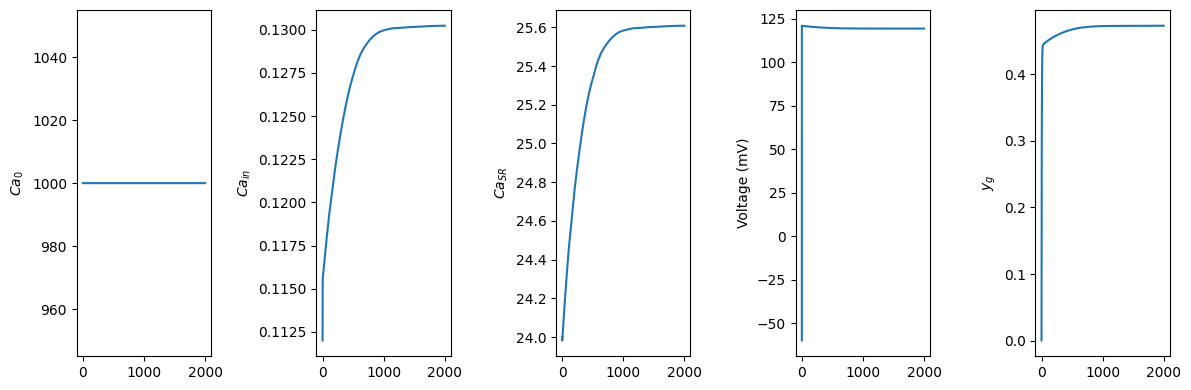

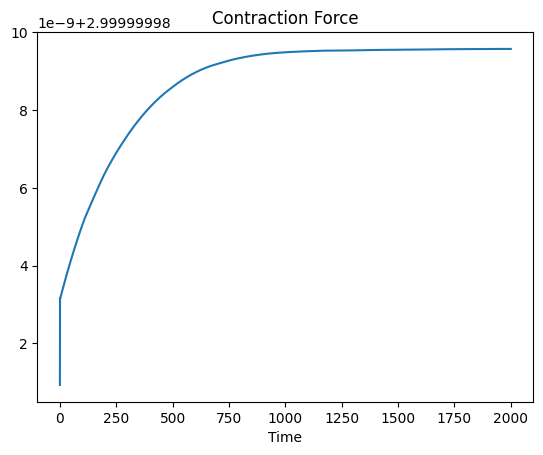

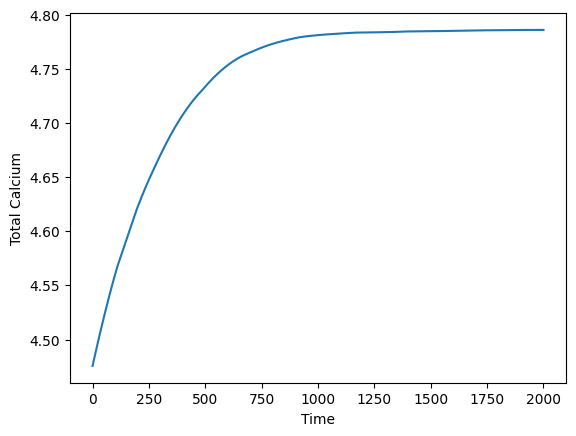

In [47]:
params = {
    # Calcium flux parameters
    "k_PMCA": 0.4,      # Wang extrusion rate 
    "V_Pmax": 4.5,      # Wang PMCA pump max rate 
    "V_s": 4.5,         # Wang/Lytton SR uptake rate max for SERCA pump between 0.1 and 0.5
    "k_s": 0.1,         # Wang/Lytton SR uptake affinity for SERCA pump between 0.1 and 0.5 
    "k_leak": 0.1,      # Wang SR leak
    "F": 96485.3329,    # Physical Faraday's constant 

    "P": 0, # IP3 production proxy by agonist 
    "c_m": 0.01, #from Lata - maybe vary?

    "gamma": 5.5,
    "delta": 0.05,

    "g_Ca": 9.0,        # Wang nS mM^-1 
    "V_m": -50.0,       # Wang mV 
    "k_m": 12.0,        # Wang mV 
    "R": 8314,         # Physical mJ/(mol K)
    "T": 310.0,          # Wang K (37°C) 

    "a_0": 0.05, # Wang
    "a_1": 0.25, # Wang
    "a_2": 1, # Wang

    "k_1": 2000, # Wang,. DeY 
    "k_-1": 260, # Wang, DeY
    "K_1": 0.13, # Wang, DeY - derived 
    "k_2": 1, # Wang, DeY
    "k_-2": 1.05, # Wang, DeY
    "K_2": 1.05, # Wang, DeY - derived
    "k_3": 2000, # Wang, DeY
    "k_-3": 1886, # Wang, DeY
    "K_3": 0.943, # Wang, DeY - derived
    "k_4": 1, # Wang, DeY
    "k_-4": 0.145, # Wang, DeY
    "K_4": 0.145, # Wang, DeY - derived
    "k_5": 100, # Wang, DeY
    "k_-5": 8.2, # Wang, DeY
    "K_5": 0.082, # Wang, DeY - derived

    # Channel gains
    "k_IP3R": 5.55, #Wang
    "k_RyR": 5.0, #Wang 
    "k_ryr0": 0.0072, # Wang and Friel RyR opening rate
    "k_ryr1": 0.334, # Wang and Friel and Shannon RyR closing rate
    "k_ryr2": 0.5, # Wang and Friel and Shannon RyR activation affinity
    "k_ryr3": 38.0, # Wang and Shannon RyR inactivation affinity

    # Contraction
    "alpha": 3.0, #Lata - uterine
    "beta": 0.001, #Lata - uterine
    "n_F": 4, # Lata - uterine

    # Functional parameters
    "n": 4, # Wang - Hill coefficient for SERCA channel activation 1, 2 or 4
    "ns": 2, # Wang and Lytton
    "n2": 3 # Wang 3 or 5 
}


def J_in_Wang(V, Ca_in, Ca_0, p):
    return p["a_0"]-p["a_1"]*I_Ca(V, Ca_in, Ca_0, p)/(2*p["F"]) +p["a_2"]*p["P"]  

def m_inf(V, p):
    return 1.0 / (1.0 + np.exp(-(V - p["V_m"]) / p["k_m"]))

def V_Ca(V, Ca_in, Ca_0, p):
    F = p["F"]
    R = p["R"]
    T = p["T"]

    exp_term = np.exp(-2.0 * V * F / (R * T))

    denom = 1.0 - exp_term
    if np.abs(denom) < 1e-8:
        return 1e-8

    return V * (Ca_in - Ca_0 * exp_term) / denom

def V_Ca(V, Ca_in, Ca_0, p):

    F = p["F"]

    R = p["R"]

    T = p["T"]

    a = 2.0 * V * F / (R * T)

    denom = -np.expm1(-a)   # 1 - exp(-a), numerically stable

    if np.abs(a) < 1e-6:

        # limit as V -> 0

        return (R * T / (2.0 * F)) * (Ca_in - Ca_0)

    return V * (Ca_in - Ca_0 * np.exp(-a)) / denom

def I_Ca(V, Ca_in, Ca_0, p):
    m = m_inf(V, p)
    Vca = V_Ca(V, Ca_in, Ca_0, p)
    return p["g_Ca"] * (m**2) * Vca

def J_PMCA(Ca_0, Ca_in, p):
    return p["k_PMCA"] * (Ca_in - Ca_0)

def J_PMCA_Hill(Ca_in, p):
    return p["V_Pmax"] * (Ca_in**p["n"]) / (p["k_PMCA"]**p["n"] + Ca_in**p["n"]) # - Ca_0**p["n"]

def J_SERCA(Ca_0, Ca_in, p):
    return p["V_s"] * (Ca_in - Ca_0)

def J_SERCA_Hill(Ca_in, p):
    return p["V_s"] * (Ca_in**p["ns"]) / (p["k_s"]**p["ns"] + Ca_in**p["ns"]) # - Ca_0**p["n"]

def J_leak(Ca_SR, Ca_in, p):
    return p["k_leak"] * (Ca_SR - Ca_in)

def J_IP3R(Ca_SR, Ca_in, p):
    return p["k_IP3R"] * (Ca_SR - Ca_in)

def J_IP3R_Wang(Ca_SR, Ca_in, y_g, p):
    return p["k_IP3R"] * P_IP3R(Ca_in, y_g, p) * (Ca_SR - Ca_in)

def P_IP3R(Ca_in, y, p):
    num = p["P"] * Ca_in * (1 - y)
    den = (p["P"] + p["K_1"]) * (Ca_in + p["K_5"])
    return (num / den) ** 3

def dy_dt(y, p, Ca_in):
    f1 = (p["k_-4"] * p["K_2"] * p["K_1"] + p["k_-2"] * p["K_4"] * p["P"]) * Ca_in / (p["K_4"] * p["K_2"] * (p["K_1"] + p["P"]))
    f2 = (p["k_-2"] * p["P"] + p["k_-4"] * p["K_3"]) / (p["K_3"] + p["P"])
    return f1 * (1.0 - y) - f2 * y

def J_RyR_Hill(Ca_SR, Ca_in, p):
    return p["k_RyR"] * (Ca_SR**p["n"]/(p["K_RyR"]**p["n"]+Ca_SR**p["n"])) * (Ca_SR - Ca_in)

def J_RyR_Wang(Ca_SR, Ca_in, p):
    return p["k_RyR"] * P_RyR(Ca_in, Ca_SR, p) * (Ca_SR - Ca_in)

def P_RyR(Ca_in, Ca_SR, p):
    # CICR activation term (cytosolic Ca)
    activation = (
        p["k_ryr0"]
        + (p["k_ryr1"] * Ca_in**3) / (p["k_ryr2"]**3 + Ca_in**3)
    )

    # SR load dependence
    sr_term = Ca_SR**4 / (p["k_ryr3"]**4 + Ca_SR**4)

    return activation * sr_term

def contraction(Ca_in, p):
    return (p["alpha"] * Ca_in**p["n_F"] / (p["beta"]**p["n_F"] + Ca_in**p["n_F"])) 

def model(t, state, p):
    Ca_0, Ca_in, Ca_SR, V, y_g = state

    # Fluxes
    Jin = J_in_Wang(V, Ca_in, Ca_0, p)
    JPMCA = J_PMCA_Hill(Ca_in, p)
    JSERCA = J_SERCA_Hill(Ca_in, p)

    dyg_dt = dy_dt(y_g, p, Ca_in)

    Jip3r = J_IP3R_Wang(Ca_SR, Ca_in, y_g, p)
    Jryr = J_RyR_Wang(Ca_SR, Ca_in, p)
    Jleak = J_leak(Ca_SR, Ca_in, p)

    # Calcium dynamics
    dCa0_dt = 0
    dCain_dt = p["delta"]*(Jin - JPMCA) - JSERCA + Jip3r + Jryr + Jleak
    dCaSR_dt = p["gamma"]*(JSERCA - Jip3r - Jryr - Jleak)

    # Membrane voltage (simple RC model)
    dV_dt = -1/p["c_m"]*(I_Ca(V, Ca_in, Ca_0, p) )

    return [dCa0_dt, dCain_dt, dCaSR_dt, dV_dt, dyg_dt]

y0 = [1000, 0.112, 24, -60, 0]  # initial conditions for Ca_0, Ca_in, Ca_SR, V, y_g Wang 

t_span = (0, 2000)
t_eval = np.linspace(*t_span, 10000)

sol = solve_ivp(model, t_span, y0, args=(params,), t_eval=t_eval, method='BDF')

# Extract variables
Ca_0 = sol.y[0]
Ca_in = sol.y[1]
Ca_SR = sol.y[2]
V = sol.y[3]
y_g = sol.y[4]
F = contraction(Ca_in, params)

plt.figure(figsize=(12, 4))
plt.subplot(1,5,1)
plt.plot(sol.t, Ca_0, label="Ca_0")
plt.ylabel(r"$Ca_{0}$")
plt.subplot(1,5,2)
plt.plot(sol.t, Ca_in, label="Ca_in")
plt.ylabel(r"$Ca_{in}$")
plt.subplot(1,5,3)
plt.plot(sol.t, Ca_SR, label="Ca_SR")
plt.ylabel(r"$Ca_{SR}$")
plt.subplot(1,5,4)
plt.plot(sol.t, V, label="V")
plt.ylabel("Voltage (mV)")
plt.subplot(1,5,5)
plt.plot(sol.t, y_g, label="y_g")
plt.ylabel(r"$y_g$")
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(sol.t, F, label="Force (F)")
plt.title("Contraction Force")
plt.xlabel("Time")
plt.show()

plt.figure()
# plt.plot(sol.t, Ca_0+(1/(params["delta"]))*Ca_in+(1/(params["delta"]))*(1/params["gamma"])*Ca_SR, label="Total Calcium")
plt.plot(sol.t, Ca_in+(1/params["gamma"])*Ca_SR, label="Total Calcium")
plt.xlabel("Time")
plt.ylabel("Total Calcium")
plt.show()

# Find the steady states numerically

In [48]:
def residuals(x, p):
    C_0, C_in, C_SR, V, y = x
    Jin = J_in_Wang(V, C_in, C_0, p)
    Jpm = J_PMCA_Hill(C_in, p)
    Jserca = J_SERCA_Hill(C_in, p)
    Jip3r = J_IP3R_Wang(C_SR, C_in, y, p)
    Jryr = J_RyR_Wang(C_SR, C_in, p)
    Jleak = J_leak(C_SR, C_in, p)
    Ica = I_Ca(V, C_in, C_0, p)
    
    F = np.zeros(5)
    F[0] = 0
    #Jpm - Jin
    F[1] = p["delta"]*(Jin - Jpm) - Jserca + Jip3r + Jryr + Jleak
    F[2] = p["gamma"]*(Jserca - Jip3r - Jryr - Jleak)
    F[3] =  -1/p["c_m"] * Ica
    f1 = (p["k_-4"] * p["K_2"] * p["K_1"] + p["k_-2"] * p["K_4"] * p["P"]) * C_in / (p["K_4"] * p["K_2"] * (p["K_1"] + p["P"]))
    f2 = (p["k_-2"] * p["P"] + p["k_-4"] * p["K_3"]) / (p["K_3"] + p["P"])
    F[4] = f1 * (1.0 - y) - f2 * y

    return F

def solve_with_root(x0, p):

    lower_bound = [0, 0, 0, -100, 0]

    sol = least_squares(
        lambda x: residuals(x, p),
        x0,
        bounds=(lower_bound, np.inf),
        method="trf",
        x_scale="jac",
        ftol=1e-12,
        xtol=1e-12,
        gtol=1e-12,
        max_nfev=10000,
        )

    return {
        "x": sol.x,
        "success": sol.success,
        "message": sol.message,
        "fun": sol.fun,
        "nfev": sol.nfev,
        "status": sol.status,
    }

if __name__ == "__main__":

    x0 = np.mean(sol.y[:,-100:], axis=1)
    out = solve_with_root(x0, params)

    print("Single solve")
    print("Success:", out["success"])
    print("Message:", out["message"])
    print("Steady state:", out["x"])
    print("Residuals:", out["fun"])
    print()

Single solve
Success: True
Message: `xtol` termination condition is satisfied.
Steady state: [9.99989531e+02 1.30230435e-01 2.56076847e+01 1.19486478e+02
 4.73168728e-01]
Residuals: [ 0.00000000e+00  5.41788836e-14 -3.00426350e-13  2.98515876e-12
 -3.46944695e-16]



# Tidy the code (set Ca_0 as a parameter) and perform bifurcation analysis

In [49]:
def rhs(x, p):
    Ca_in, Ca_SR, V, y_g = x
    Ca_0 = p["Ca_0"]

    Jin = J_in_Wang(V, Ca_in, Ca_0, p)
    Jpm = J_PMCA_Hill(Ca_in, p)
    Jserca = J_SERCA_Hill(Ca_in, p)
    Jip3r = J_IP3R_Wang(Ca_SR, Ca_in, y_g, p)
    Jryr = J_RyR_Wang(Ca_SR, Ca_in, p)
    Jleak = J_leak(Ca_SR, Ca_in, p)
    dV_dt = -1/p["c_m"]*(I_Ca(V, Ca_in, Ca_0, p) )

    dCain_dt = p["delta"] * (Jin - Jpm) - Jserca + Jip3r + Jryr + Jleak
    dCaSR_dt = p["gamma"] * (Jserca - Jip3r - Jryr - Jleak)
    dV_dt = -1/p["c_m"] * I_Ca(V, Ca_in, Ca_0, p)
    dyg_dt = dy_dt(y_g, p, Ca_in)

    return np.array([dCain_dt, dCaSR_dt, dV_dt, dyg_dt])

def jacobian_fd(f, x, p, eps=1e-6):
    x = np.asarray(x, dtype=float)
    f0 = f(x, p)
    n = len(x)
    J = np.zeros((len(f0), n))
    for i in range(n):
        dx = np.zeros(n)
        dx[i] = eps
        fp = f(x + dx, p)
        fm = f(x - dx, p)
        J[:, i] = (fp - fm) / (2 * eps)
    return J

# def continue_branch(param_name, values, x0, p0):
#     branch = []
#     x_guess = np.array(x0, dtype=float)
#     for mu in values:
#         p = dict(p0)
#         p[param_name] = mu
#         sol = root(lambda x: rhs(x, p), x_guess, method="hybr")
#         if not sol.success:
#             branch.append((mu, np.nan, np.nan, np.nan, np.nan, np.nan))
#             continue
#         x_ss = sol.x
#         J = jacobian_fd(rhs, x_ss, p)
#         eig = np.linalg.eigvals(J)
#         branch.append((mu, *x_ss, np.max(np.real(eig))))
#         x_guess = x_ss
#     return np.array(branch)

def continue_branch(param_name, values, x0, p0):
    branch = []
    x_guess = np.array(x0, dtype=float)
    for mu in values:
        p = dict(p0)
        p[param_name] = mu
        sol = root(lambda x: rhs(x, p), x_guess, method="hybr")
        # print("mu =", mu, "success =", sol.success, "message =", sol.message)
        if not sol.success:
            branch.append((mu, np.nan, np.nan, np.nan, np.nan, np.nan))
            continue
        x_ss = sol.x
        J = jacobian_fd(rhs, x_ss, p)
        eig = np.linalg.eigvals(J)
        branch.append((mu, *x_ss, np.max(np.real(eig))))
        x_guess = x_ss
    return np.array(branch)

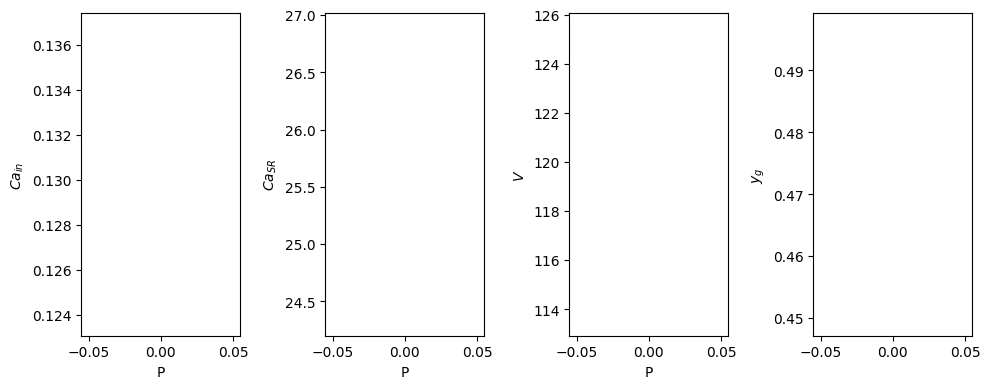

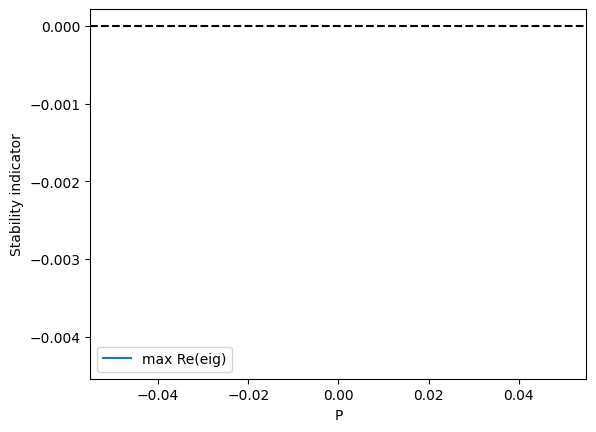

In [50]:
params["Ca_0"] = out["x"][0]  # Fix Ca_0 to the value found in the steady state solve
P_values = np.linspace(0, 2.0, 200)
x0 = out["x"][-4:]
# np.array([0.112, 24.0, -60, 0.0])   # [Ca_in, Ca_SR, y_g]
branch = continue_branch("P", P_values, x0, params)

plt.figure(figsize=(10, 4))
plt.subplot(1,4,1)
plt.plot(branch[:,0], branch[:,1], label="Ca_in")
plt.xlabel("P")
plt.ylabel(r"$Ca_{in}$")
plt.subplot(1,4,2)
plt.plot(branch[:,0], branch[:,2], label="Ca_SR")
plt.xlabel("P")
plt.ylabel(r"$Ca_{SR}$")
plt.subplot(1,4,3)
plt.plot(branch[:,0], branch[:,3], label="V")
plt.xlabel("P")
plt.ylabel(r"$V$")
plt.subplot(1,4,4)
plt.plot(branch[:,0], branch[:,4], label="y_g")
plt.ylabel(r"$y_g$")
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(branch[:,0], branch[:,5], label="max Re(eig)")
plt.axhline(0, color="k", linestyle="--")
plt.xlabel("P")
plt.ylabel("Stability indicator")
plt.legend()
plt.show()

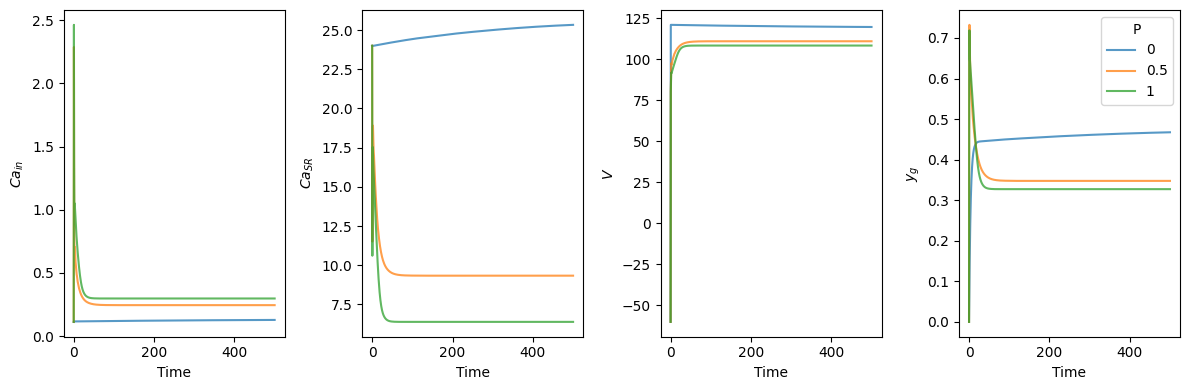

In [51]:
Ps = [0, 0.5, 1]

t_span = (0, 500)
t_eval = np.linspace(*t_span, 1000)

colors = plt.cm.viridis(np.linspace(0, 1, len(Ps)))
colors = plt.cm.tab10(np.arange(len(Ps)))
fig, axes = plt.subplots(1, 4, figsize=(12, 4), sharex=True)
for i, P in enumerate(Ps):
    p = dict(params)
    p["P"] = P
    sol = solve_ivp(model, t_span, y0, args=(p,), t_eval=t_eval, method='BDF')
    Ca_in = sol.y[1]
    Ca_SR = sol.y[2]
    V = sol.y[3]
    y_g = sol.y[4]
    axes[0].plot(sol.t, Ca_in, color=colors[i], alpha=0.75)
    axes[1].plot(sol.t, Ca_SR, color=colors[i], alpha=0.75)
    axes[2].plot(sol.t, V, color=colors[i], alpha=0.75)
    axes[3].plot(sol.t, y_g, color=colors[i], label=f"{P}", alpha=0.75)
axes[0].set_ylabel(r"$Ca_{in}$")
axes[1].set_ylabel(r"$Ca_{SR}$")
axes[2].set_ylabel(r"$V$")
axes[3].set_ylabel(r"$y_g$")
for ax in axes:
    ax.set_xlabel("Time")
axes[3].legend(title="P")
plt.tight_layout()
plt.show()

In [52]:
def dF_dpar(x, p, par_name, eps=1e-6):
    p1 = dict(p)
    p2 = dict(p)
    p1[par_name] = p[par_name] + eps
    p2[par_name] = p[par_name] - eps
    return (rhs(x, p1) - rhs(x, p2)) / (2.0 * eps)

def tangent_at(x, p, par_name, prev=None):
    A = np.column_stack([jacobian_fd(rhs, x, p), dF_dpar(x, p, par_name)])
    _, _, VT = np.linalg.svd(A)
    t = VT[-1, :]
    t = t / np.linalg.norm(t)

    if prev is not None and np.dot(t, prev) < 0:
        t = -t

    return t

def corrector(z_pred, t, p_base, par_name):

    def G(z):

        x = z[:4]

        mu = z[4]

        p = dict(p_base)

        p[par_name] = mu

        eq = rhs(x, p)

        arc = np.dot(z - z_pred, t)

        return np.hstack([eq, arc])

    return root(G, z_pred, method="hybr")

def continue_psa(x0, mu0, p_base, par_name="P", ds=1e-4, n_steps=200):
    p0 = dict(p_base)
    p0[par_name] = mu0

    sol0 = root(lambda x: rhs(x, p0), x0, method="hybr")
    if not sol0.success:
        raise RuntimeError("Initial equilibrium solve failed: " + sol0.message)

    x = sol0.x
    z = np.array([x[0], x[1], x[2], x[3], mu0], dtype=float)

    t = tangent_at(x, p0, par_name)

    branch = []
    for k in range(n_steps):
        p_now = dict(p_base)
        p_now[par_name] = z[4]

        J = jacobian_fd(rhs, z[:4], p_now)
        eig = np.linalg.eigvals(J)

        branch.append({
            par_name: z[4],
            "Ca_in": z[0],
            "Ca_SR": z[1],
            "V": z[2],
            "y_g": z[3],
            "eig": eig,
            "max_real": np.max(np.real(eig)),
            "tmu": t[4],
        })

        z_pred = z + ds * t
        sol = corrector(z_pred, t, p_base, par_name)

        if not sol.success:
            print(f"Corrector failed at step {k}: {sol.message}")
            break

        z_new = sol.x
        p_new = dict(p_base)
        p_new[par_name] = z_new[4]

        t_new = tangent_at(z_new[:4], p_new, par_name, prev=t)

        z = z_new
        t = t_new

    return branch

x0 = out["x"][-4:]
branch = continue_psa(x0, mu0=params["P"], p_base=params, par_name="P", ds=1e-4, n_steps=50000)

P_vals = np.array([b["P"] for b in branch])
Ca_in_vals = np.array([b["Ca_in"] for b in branch])
Ca_SR_vals = np.array([b["Ca_SR"] for b in branch])
V_vals = np.array([b["V"] for b in branch])
y_vals = np.array([b["y_g"] for b in branch])
stab = np.array([b["max_real"] for b in branch])

stable = stab < 0

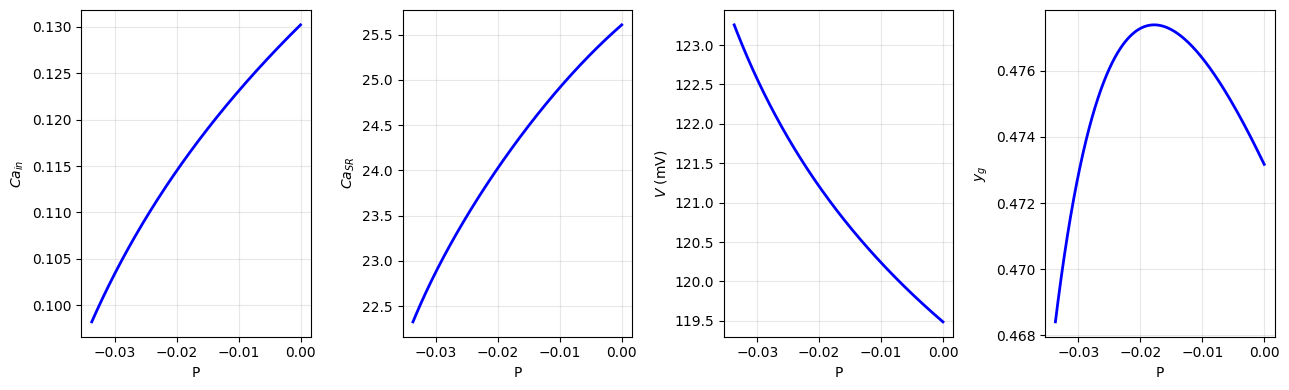

In [53]:
fig, axes = plt.subplots(1, 4, figsize=(13, 4), sharex=True)

axes[0].plot(P_vals[stable], Ca_in_vals[stable], 'b-', lw=2)
axes[0].plot(P_vals[~stable], Ca_in_vals[~stable], 'r--', lw=2)

axes[1].plot(P_vals[stable], Ca_SR_vals[stable], 'b-', lw=2)
axes[1].plot(P_vals[~stable], Ca_SR_vals[~stable], 'r--', lw=2)

axes[2].plot(P_vals[stable], V_vals[stable], 'b-', lw=2)
axes[2].plot(P_vals[~stable], V_vals[~stable], 'r--', lw=2)

axes[3].plot(P_vals[stable], y_vals[stable], 'b-', lw=2)
axes[3].plot(P_vals[~stable], y_vals[~stable], 'r--', lw=2)

for ax in axes:
    ax.set_xlabel("P")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel(r"$Ca_{in}$")
axes[1].set_ylabel(r"$Ca_{SR}$")
axes[2].set_ylabel(r"$V$ (mV)")
axes[3].set_ylabel(r"$y_g$")

plt.tight_layout()
plt.show()